# Landing Page A/B Test — Conversion & Revenue Impact Analysis

**A statistically-grounded evaluation of two landing page variants, built to support a data-driven business decision on which version to ship.**


## Business Context

This project evaluates an **A/B test** run on a product landing page, comparing **Variant A and Variant B**, to support a data-driven business decision on which version to roll out.

The dataset (`landing_experiment.csv`) contains 40,000 users exposed to one of the two landing page variants, including region, device, traffic source, user type, conversion outcome, and spend.

The analysis follows a clear, progressive structure:

1. Explore and validate the data
2. Compare **average spend** per user between Variant A and B
3. Compare the **conversion rate** between Variant A and B
4. Examine the relationship between **traffic source** and conversion
5. Examine the relationship between **user type** and conversion
6. **Visualize the results** to support the conclusions with clear charts

Appropriate statistical tests are applied throughout to compare the variants and **recommend which version performs better**, with the decision backed by data.


## 1. Load & Validate the Data

### 1.1 Data loading and quick look

In [1]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, ttest_ind, levene
from statsmodels.stats.proportion import proportions_ztest


In [2]:
# Load dataset
df = pd.read_csv('/datasets/landing_experiment.csv')

df = df.rename(columns={
    'landing': 'variant',
    'dispositivo': 'device',
    'gasto': 'spend'
})

df['region'] = df['region'].replace({
    'Norte': 'North', 'Centro': 'Central', 'Sur': 'South',
    'Occidente': 'West', 'Oriente': 'East'
})
df['user_type'] = df['user_type'].replace({'Nuevo': 'New', 'Recurrente': 'Returning'})


**Preview and general dataset info**

In [3]:
# Preview the first rows
df.head()


,user_id,date,variant,region,device,traffic_source,user_type,converted,spend
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,North,Mobile,Email,Returning,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,West,Mobile,Organic,New,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Central,Mobile,Organic,New,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Central,Mobile,Ads,New,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,South,Mobile,Organic,New,0,0.00


In [4]:
# General info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   variant         40000 non-null  object 
 3   region          40000 non-null  object 
 4   device          40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   spend           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


In [5]:
df.isnull().sum().sum()


0

**Observations — Initial load and data types**

- The dataset contains **40,000 records** and **9 columns**, with no missing values in any variable.
- All numeric columns (`converted`, `spend`) have the correct data type: `int64` and `float64` respectively.
- No structural issues were found that require correction before continuing the analysis.


**Dataset description**

| Column | Description |
|---|---|
| `user_id` | Unique user identifier |
| `date` | Date the user was exposed to the page |
| `variant` | Page version shown to the user (A or B) |
| `region` | User's geographic region |
| `device` | Device type used by the user |
| `traffic_source` | Channel through which the user arrived |
| `user_type` | User type based on prior history |
| `converted` | Whether the user converted |
| `spend` | Amount spent by the user (0 if not converted) |


In [6]:
df['date'] = pd.to_datetime(df['date'])


In [7]:
df["date"].dtype


dtype('<M8[ns]')

### 1.2 Exploratory analysis and data quality review

The key A/B test variables are identified, and we validate that they're well-defined, complete, and consistent.

**`user_id`** — verify unique users

In [8]:
df["user_id"].nunique()


40000

**`date`** — explore date range

In [9]:
# Statistical summary
df["date"].describe()


count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [10]:
# Identify the experiment's time range
print("Min date:", df["date"].min())
print("Max date:", df["date"].max())


Min date: 2026-01-01 00:00:00
Max date: 2026-01-28 00:00:00


**`spend`** (numeric)

In [11]:
df["spend"].describe()


count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: spend, dtype: float64

In [12]:
df["converted"].describe()


count    40000.00000
mean         0.14265
std          0.34972
min          0.00000
25%          0.00000
50%          0.00000
75%          0.00000
max          1.00000
Name: converted, dtype: float64

**Categorical variables** — verify the expected experiment categories (A and B)

In [13]:
categorical_cols = ['variant', 'region', 'device', 'traffic_source', 'user_type']

print("=== CATEGORICAL VARIABLE EXPLORATION ===")

for col in categorical_cols:
    print("\n" + "="*40)
    print(f"Variable: {col.upper()}")
    print("="*40)

    print("Absolute count:")
    print(df[col].value_counts())

    print("\nProportion (%):")
    print((df[col].value_counts(normalize=True) * 100).round(2).astype(str) + '%')


=== CATEGORICAL VARIABLE EXPLORATION ===

Variable: VARIANT
Absolute count:
B    20018
A    19982
Name: variant, dtype: int64

Proportion (%):
B    50.04%
A    49.96%
Name: variant, dtype: object

Variable: REGION
Absolute count:
North      11166
Central     9613
South       8039
West        6398
East        4784
Name: region, dtype: int64

Proportion (%):
North      27.92%
Central    24.03%
South       20.1%
West        16.0%
East       11.96%
Name: region, dtype: object

Variable: DEVICE
Absolute count:
Mobile     24829
Desktop    15171
Name: device, dtype: int64

Proportion (%):
Mobile     62.07%
Desktop    37.93%
Name: device, dtype: object

Variable: TRAFFIC_SOURCE
Absolute count:
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

Proportion (%):
Organic     44.97%
Ads         29.84%
Email       15.31%
Referral     9.89%
Name: traffic_source, dtype: object

Variable: USER_TYPE
Absolute count:
New          26033
Returning    

In [14]:
# 1. Explicitly check for duplicate user_id
print("Duplicate user_id count:", df['user_id'].duplicated().sum())

# 2. Spend summary for converted users only (converted == 1)
print("\n--- Spend summary (converted users) ---")
print(df[df['converted'] == 1]['spend'].describe())


Duplicate user_id count: 0

--- Spend summary (converted users) ---
count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: spend, dtype: float64


**Observations — Categorical variables and experiment data quality**

- `user_id`: all 40,000 records correspond to 40,000 unique users — no duplicates, no user exposed to more than one variant.
- `date` was successfully converted from `object` to `datetime64` to enable time-based analysis.
- `date`: the experiment covers the full month of January 2026 (1st through 28th).
- `variant`: balanced distribution between groups — A: 49.96% (19,982) and B: 50.04% (20,018). The experiment is correctly designed.
- `region`: five regions present (North, Central, South, West, East), all expected values — no spelling errors or unexpected categories.
- `device`: two clean categories (Mobile, Desktop) — no anomalies.
- `traffic_source`: four channels present (Organic, Ads, Email, Referral) — all expected.
- `user_type`: two clean categories (New, Returning) — no anomalies.
- `spend`: 85.7% of values are 0.00, corresponding to non-converted users — structurally correct. Restricting the analysis to the 5,706 users who converted (`converted == 1`), average spend is 65.37, median 59.86, minimum 12.12, and maximum $303.68.
- `converted`: overall conversion rate of 14.27% — consistent with typical e-commerce A/B tests.

**Conclusion:** the dataset shows no data quality issues and is ready for statistical analysis.


## 2. Compare Average Spend per User (Variant A vs. B)

We test whether there's a statistically significant difference in average spend among **converted users** between Variant A and Variant B, to identify which version generates greater economic value for the business.

In [15]:
# Spend by variant
spend_A = df[(df['variant'] == 'A') & (df['converted'] == 1)]['spend']
spend_B = df[(df['variant'] == 'B') & (df['converted'] == 1)]['spend']

# Check sample size for each group
len(spend_A), len(spend_B)


(2512, 3194)

In [16]:
print("Average spend Variant A:", spend_A.mean())
print("Average spend Variant B:", spend_B.mean())


Average spend Variant A: 61.0865724522293
Average spend Variant B: 68.74536005009392


### Student's t-test to compare average spend (A vs. B)

**Hypotheses:**
- **Null hypothesis (H₀):** average customer spend is equal between Variant A and Variant B.
- **Alternative hypothesis (H₁):** average customer spend differs between Variant A and Variant B.


In [17]:
# Run the test
t_stat, p_value = ttest_ind(spend_A, spend_B)

print(f"t-statistic: {t_stat}")
print(f"p-value: {p_value}")


t-statistic: -9.36563589591332
p-value: 1.0635288333792346e-20


In [18]:
# Levene's test for homogeneity of variance
stat_lev, p_lev = levene(spend_A, spend_B)
print(f"Levene's test - statistic: {stat_lev:.4f}, p-value: {p_lev:.4e}")

# If p_lev > 0.05, variances are equal (equal_var=True). Otherwise, equal_var=False.
equal_variances = p_lev > 0.05

# Run Student's t-test specifying equal_var
t_stat, p_value = ttest_ind(spend_A, spend_B, equal_var=equal_variances)

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4e}")


Levene's test - statistic: 29.1765, p-value: 6.8753e-08
t-statistic: -9.4810
p-value: 3.6276e-21


### Conclusion & interpretation

**Decision:** Levene's test returned p = 6.88e-08 < 0.05, indicating the variances of both groups are not equal. Welch's t-test was therefore applied (`equal_var=False`). With p = 3.63e-21 (well below α = 0.05), **we reject the null hypothesis H₀.**

There's sufficient statistical evidence that average spend among converted users differs between Variant A and Variant B.

**Business interpretation**

Converted users exposed to Variant B spent an average of 68.75, compared to 61.09 for Variant A — a difference of **$7.66 per purchase**, roughly a **12.5%** increase in average transaction value.

In practical terms, for every 1,000 conversions, Variant B would generate approximately $7,660 in additional revenue compared to Variant A, holding all other conditions constant.

This suggests Variant B isn't just associated with more conversions — it's also associated with higher-value purchases. The next step evaluates whether this advantage also shows up in conversion rate, which would confirm whether Variant B outperforms on both volume and value.


## 3. Compare Conversion Rate (Variant A vs. B)

We test whether there's a statistically significant difference in **conversion rate** between Variant A and B, to identify which version generates a higher number of converted users.

### Z-test for proportions to compare conversion rate (A vs. B)

**Hypotheses:**
- **Null hypothesis (H₀):** the conversion rate is equal between Variant A and Variant B.
- **Alternative hypothesis (H₁):** the conversion rate differs between Variant A and Variant B.


In [19]:
# Number of converted users per variant
conversions = df.groupby('variant')['converted'].sum()

# Total users per variant
totals = df.groupby('variant')['converted'].count()

print("Converted users by variant:\n", conversions)
print("\nTotal users by variant:\n", totals)


Converted users by variant:
 variant
A    2512
B    3194
Name: converted, dtype: int64

Total users by variant:
 variant
A    19982
B    20018
Name: converted, dtype: int64


In [20]:
conversion_rates = df.groupby('variant')['converted'].mean() * 100

print("--- Actual conversion rates ---")
print(f"Variant A conversion rate: {conversion_rates['A']:.2f}%")
print(f"Variant B conversion rate: {conversion_rates['B']:.2f}%")


--- Actual conversion rates ---
Variant A conversion rate: 12.57%
Variant B conversion rate: 15.96%


In [21]:
# Run the test
z_stat, p_value = proportions_ztest(conversions, totals)

print(f"z-statistic: {z_stat}")
print(f"p-value: {p_value}")


z-statistic: -9.677362674655983
p-value: 3.7629765627523803e-22


### Conclusion & interpretation

**Decision:** with p = 3.76e-22 (practically zero), well below α = 0.05, we **reject the null hypothesis H₀**.

There's strong statistical evidence that the conversion rate differs between Variant A and Variant B.

**Business interpretation**

Variant B converts **15.96%** of its users, versus **12.57%** for Variant A — a difference of **3.39 percentage points**. This result is statistically significant and not attributable to chance. In practical terms, for every 10,000 users exposed, Variant B generates roughly 339 additional conversions relative to Variant A.

This aligns with the spend finding above: Variant B doesn't just convert more users — it also extracts more economic value per converting user ($68.75 vs. $61.09 on average). Together, these two results build a strong case for Variant B, developed further in the executive insight section below.


## 4. Traffic Source vs. Conversion

We test whether there's a statistically significant association between **traffic source** and **conversion**, to identify which channels drive more conversions.

### Chi-square test — traffic source and conversion

**Hypotheses:**
- **Null hypothesis (H₀):** conversion is independent of traffic source.
- **Alternative hypothesis (H₁):** there's an association between traffic source and conversion.


In [22]:
# 1. Contingency table (absolute count) and normalized (%)
table = pd.crosstab(df['traffic_source'], df['converted'])
table_traffic_norm = pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100

# 2. Chi-square test
chi2_stat, p_value, dof, expected = chi2_contingency(table)

# 3. Expected frequencies DataFrame
df_expected_traffic = pd.DataFrame(expected, index=table.index, columns=['Not converted (0)', 'Converted (1)'])

print("=== 1. NORMALIZED TABLE BY TRAFFIC SOURCE (%) ===")
print(table_traffic_norm.round(2))

print("\n=== 2. CHI-SQUARE TEST ===")
print(f"Chi-square statistic: {chi2_stat:.3f}")
print(f"p-value: {p_value:.3f}")

print("\n=== 3. EXPECTED FREQUENCIES ===")
print(df_expected_traffic.round(2))


=== 1. NORMALIZED TABLE BY TRAFFIC SOURCE (%) ===
converted           0      1
traffic_source              
Ads             85.26  14.74
Email           85.01  14.99
Organic         86.21  13.79
Referral        86.12  13.88

=== 2. CHI-SQUARE TEST ===
Chi-square statistic: 8.662
p-value: 0.034

=== 3. EXPECTED FREQUENCIES ===
                Not converted (0)  Converted (1)
traffic_source                                  
Ads                      10232.47        1702.53
Email                     5249.55         873.45
Organic                  15421.15        2565.85
Referral                  3390.82         564.18


### Conclusion & interpretation

**Decision:** with χ² = 8.662 and p = 0.034, below α = 0.05, **we reject the null hypothesis H₀**.

There's sufficient statistical evidence that traffic source and conversion aren't independent — the acquisition channel does influence purchase propensity.

**Business interpretation**

While **Organic** accounts for the largest absolute volume of conversions (2,480), conversion *rate* by channel reveals more relevant differences:

- Email: 14.99%
- Ads: 14.74%
- Referral: 13.88%
- Organic: 13.79%

Email and Ads show slightly higher conversion effectiveness than Referral and Organic. This suggests not all channels convert equally efficiently, and shifting budget toward Email and Ads could improve marketing spend efficiency, independent of the raw traffic volume each channel generates.


## 5. User Type vs. Conversion

We test whether there's a statistically significant association between **user type** and **conversion**, recognizing that a returning user may have visited before without necessarily converting this time.

The goal is to identify which profiles show a higher likelihood of conversion within this context.

### Chi-square test — user type and conversion

**Hypotheses:**
- **Null hypothesis (H₀):** conversion is independent of user type.
- **Alternative hypothesis (H₁):** there's an association between user type and conversion.


In [23]:
# 1. Contingency table (absolute count) and normalized (%)
table_type = pd.crosstab(df['user_type'], df['converted'])
table_type_norm = pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100

# 2. Chi-square test
chi2_stat, p_value, dof, expected = chi2_contingency(table_type)

# 3. Expected frequencies DataFrame
df_expected_type = pd.DataFrame(expected, index=table_type.index, columns=['Not converted (0)', 'Converted (1)'])

print("=== 1. NORMALIZED TABLE BY USER TYPE (%) ===")
print(table_type_norm.round(2))

print("\n=== 2. CHI-SQUARE TEST ===")
print(f"Chi-square statistic: {chi2_stat:.3f}")
print(f"p-value: {p_value:.3f}")

print("\n=== 3. EXPECTED FREQUENCIES ===")
print(df_expected_type.round(2))


=== 1. NORMALIZED TABLE BY USER TYPE (%) ===
converted      0      1
user_type              
New        85.64  14.36
Returning  85.91  14.09

=== 2. CHI-SQUARE TEST ===
Chi-square statistic: 0.513
p-value: 0.474

=== 3. EXPECTED FREQUENCIES ===
           Not converted (0)  Converted (1)
user_type                                  
New                 22319.39        3713.61
Returning           11974.61        1992.39


### Conclusion & interpretation

**Decision:** with χ² = 0.513 and p = 0.474, well above α = 0.05, **we fail to reject the null hypothesis H₀**.

There isn't sufficient statistical evidence that conversion rate varies by user type.

**Business interpretation**

New users (14.36%) and returning users (14.09%) convert at practically identical rates, indicating that conversion probability is **independent** of whether the user is visiting the page for the first time or already knows the brand.

The difference observed in absolute values is explained by the larger volume of new users (26,033 vs. 13,967), not by a real difference in conversion behavior. This suggests **segmenting the landing page strategy by user type wouldn't provide a differential advantage** — both profiles respond similarly to Variants A and B.


## 6. Visualize Categorical Variable Results

We visually explore the relationship between categorical variables (`traffic_source` and `user_type`) and conversion, showing for each category:
- the absolute number of converted and non-converted users
- the proportion of converted vs. non-converted users

This helps read both volume impact and relative effectiveness of each category, reinforcing the statistical test results above.

### Traffic source vs. conversion

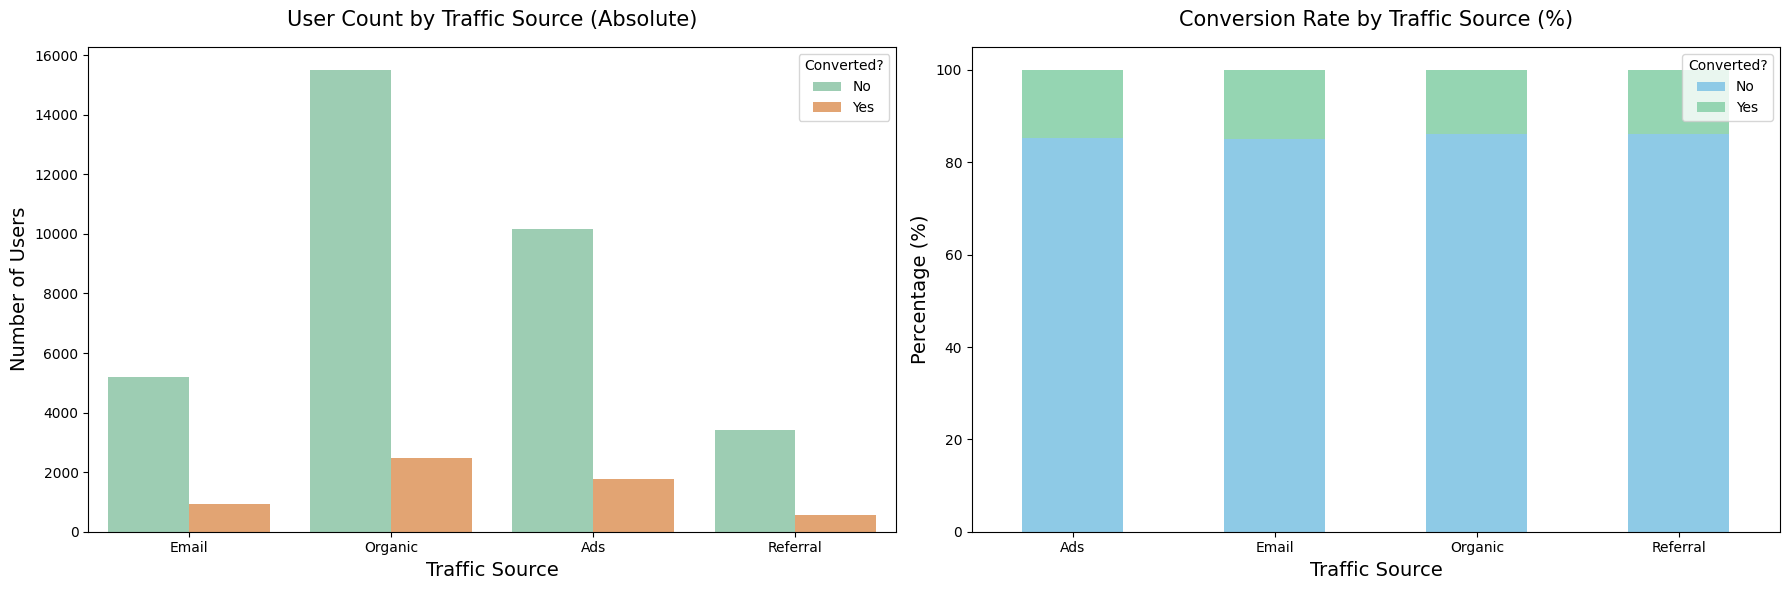

In [24]:
# 1. Build the normalized table
norm_table = pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Chart 1: Grouped bars (absolute volume) ---
sns.countplot(data=df, x='traffic_source', hue='converted', palette=["#95D5B2", "#F4A261"], ax=axes[0])
axes[0].set_title('User Count by Traffic Source (Absolute)', fontsize=15, pad=15)
axes[0].set_xlabel('Traffic Source', fontsize=14)
axes[0].set_ylabel('Number of Users', fontsize=14)
axes[0].legend(title='Converted?', labels=['No', 'Yes'])

# --- Chart 2: Stacked bars ---
norm_table.plot(kind='bar', stacked=True, color=["#8ecae6", "#95d5b2"], ax=axes[1])

axes[1].set_title('Conversion Rate by Traffic Source (%)', fontsize=15, pad=15)
axes[1].set_xlabel('Traffic Source', fontsize=14)
axes[1].set_ylabel('Percentage (%)', fontsize=14)
axes[1].legend(title='Converted?', labels=['No', 'Yes'], loc='upper right')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


**Chart analysis — traffic source**

**Conversion volume by traffic source:** Organic dominates absolute volume for both converted and non-converted users, followed by Ads. Email and Referral account for less total traffic. The high volume of non-converted users in Organic reflects its scale (most exposed users), not necessarily lower relative efficiency.

**Conversion rate by traffic source:** looking at relative rates, the differences between channels become clearer. Email and Ads show conversion proportions slightly above the global average (14.27%), while Organic and Referral stay below it. These patterns support the Section 4 statistical result: traffic source is associated with conversion, though the differences are moderate.


### User type vs. conversion

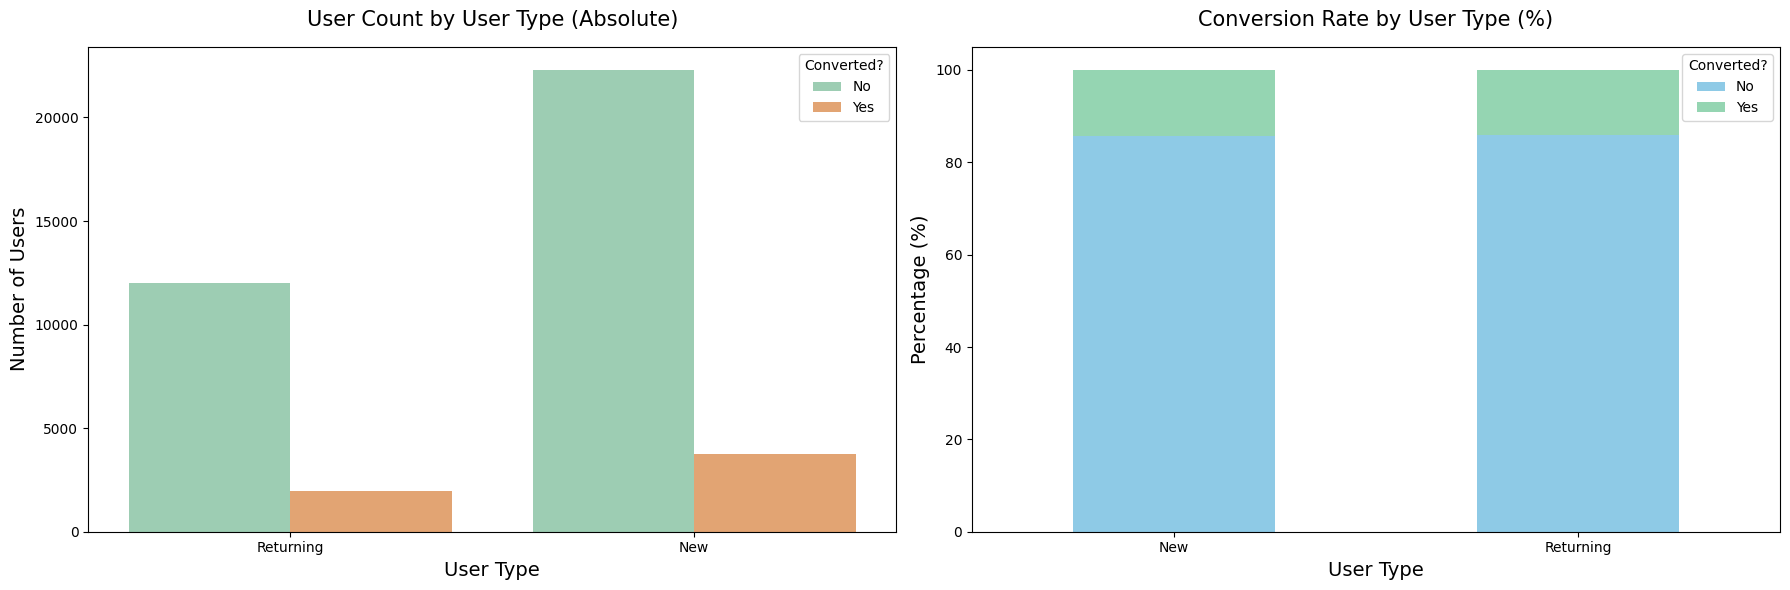

In [25]:
# Build and normalize the table for user type (New vs. Returning)
type_norm_table = pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Chart 1: Grouped bars (absolute volume) ---
sns.countplot(data=df, x='user_type', hue='converted', palette=["#95D5B2", "#F4A261"], ax=axes[0])
axes[0].set_title('User Count by User Type (Absolute)', fontsize=15, pad=15)
axes[0].set_xlabel('User Type', fontsize=14)
axes[0].set_ylabel('Number of Users', fontsize=14)
axes[0].legend(title='Converted?', labels=['No', 'Yes'])

# --- Chart 2: Stacked bars ---
type_norm_table.plot(kind='bar', stacked=True, color=["#8ecae6", "#95d5b2"], ax=axes[1])

axes[1].set_title('Conversion Rate by User Type (%)', fontsize=15, pad=15)
axes[1].set_xlabel('User Type', fontsize=14)
axes[1].set_ylabel('Percentage (%)', fontsize=14)
axes[1].legend(title='Converted?', labels=['No', 'Yes'], loc='upper right')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


**Chart analysis — user type**

**Conversion volume by user type:** new users represent the largest volume in both categories (converted and non-converted), reflecting their dominance in the dataset (65% of the total). Returning users, while fewer, show an internal split between converted and non-converted (≈14% vs. ≈86%) that's virtually identical to new users — visually anticipating that both groups behave equivalently with respect to conversion.

**Conversion rate by user type:** the stacked bars visually confirm what the chi-square test showed — conversion rates between new and returning users are practically identical (≈14.3% in both groups). There's no meaningful visual difference between the two categories, supporting the conclusion that user type isn't a differentiating factor for conversion in this experiment.


## 7. Executive Insight for Stakeholders

We translate the A/B test findings into actionable business conclusions, focused on **page variant, conversion, average spend, traffic channels, and user type**.

**Questions to answer:**
- Which variant drives higher conversion and average spend?
- Which traffic channels are most effective at generating conversions?
- Are there significant differences by user type?
- What recommendations follow for optimizing marketing strategy?


### Executive Insight — A/B Test Summary

#### Variant comparison (A vs. B)

**Average spend per converted user:**

- Variant A: **61.09** per conversion (2,512 converted users)
- Variant B: **68.75** per conversion (3,194 converted users)

**Interpretation:** the t-test confirmed this **$7.66 per transaction** difference is statistically significant (p = 1.06e-20) and not due to chance. In practical terms, for every 1,000 conversions, Variant B generates roughly $7,660 in additional revenue over Variant A — a 12.5% increase in average purchase value.

**Conversion rate:**

- Variant A: **12.57%** (2,512 of 19,982 users)
- Variant B: **15.96%** (3,194 of 20,018 users)

**Interpretation:** the Z-test confirmed the **3.39 percentage point** difference is statistically significant (p = 3.76e-22). For every 10,000 users exposed, Variant B generates roughly 339 additional conversions. Combined with the higher average spend per transaction, Variant B outperforms Variant A on both conversion volume and economic value per user.

---

#### Segmentation by traffic source

- The chi-square test found a statistically significant association between acquisition channel and conversion (χ² = 8.662, p = 0.034).
- Conversion rate by channel: **Email 14.99% · Ads 14.74% · Referral 13.88% · Organic 13.79%**

**Interpretation:** the test confirms a real association between traffic channel and conversion when considered jointly — not all channels perform the same. However, the test doesn't identify which specific channels differ significantly from each other: the gap between Email (14.99%) and Organic (13.79%), for example, hasn't been validated in isolation and might not be significant on its own.

The observed rates suggest a trend where Email and Ads slightly outperform Organic and Referral, but these should be read as exploratory signals, not definitive conclusions. Additionally, Email operates at a considerably smaller scale (15.3% of total traffic vs. 44.8% for Organic), which limits the strength of any direct comparison between the two.

**Recommendation:** investigate channel-level behavior before reallocating budget. Email and Ads show slightly higher conversion rates, but the difference between individual channels wasn't validated in isolation. The recommended next step is to design channel-specific experiments to confirm whether these differences are real and hold at scale.

---

#### Segmentation by user type

- The chi-square test found no significant difference between new and returning users (χ² = 0.513, p = 0.474).
- Conversion rate: **New 14.36% · Returning 14.09%**

**Interpretation:** both segments respond in a statistically equivalent way to the landing page. The gap in absolute volume (26,033 new vs. 13,967 returning) reflects the dataset's composition, not a real behavioral difference. This evidence doesn't justify designing differentiated page versions based on user history.

---

The Section 6 visualizations support these results: differences by traffic source are moderate but statistically real, while differences by user type are practically nonexistent in both the volume and proportion charts.

---

#### Business recommendations

- **Ship Variant B** as the definitive version — it delivers a 3.39-percentage-point higher conversion rate and $7.66 higher average spend per transaction, both backed by solid statistical evidence.
- **Design channel-specific experiments** before making budget decisions — the chi-square test confirmed a global association between traffic channel and conversion, but doesn't identify which individual channels differ significantly from one another. The observed per-channel rate differences are exploratory signals that need further validation before acting on them.
- **Don't segment the landing page by user type** — the statistical evidence doesn't support differentiating the page design or content between new and returning users.
- **Monitor post-launch performance** for 30–60 days to confirm the experiment's metrics hold up in production and to rule out seasonal effects specific to January 2026.
